In [1]:
# Task 1: Data Ingestion and Validation 11.06.26

In [2]:
#Load Dataset
import pandas as pd
import seaborn as sns
df = pd.read_csv("European_Bank.csv")

In [3]:
#To check data types and not null count
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [4]:
#To check null values
print("Null value columns:")
for i in df.columns:
    if (df[i].isna()).any():
        print(f"{i} ")

Null value columns:


In [5]:
#To check how many contain 0
print("Zero values columns:")
for i in df.columns:
    if (df[i]==0).any():
        print(f"{i} ",end="")

Zero values columns:
Tenure Balance HasCrCard IsActiveMember Exited 

In [6]:
#To check if binary values are valid
print((df['HasCrCard']>1).sum())
print((df['IsActiveMember']>1).sum())

0
0


In [7]:
#To check -ve values
print("Negative values columns:")
for i in df.select_dtypes(include='number').columns:
    if (df[i]<0).any():
        print(f"{i} ",end="")

Negative values columns:


In [8]:
#To check Churn Label Consistency
if (df['Exited'].unique()).any() in range(0,2):
    print("Churn Accuracy Validated")
print(df['Exited'].unique())

Churn Accuracy Validated
[1 0]


In [9]:
#Task 2 Data Cleaning And Preparation 12.06.26

In [10]:
#Duplicates and Irrelevant Data
print(df.duplicated().sum())
df1=df.drop(columns=['Year','Surname','CustomerId'])
df1

0


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [11]:
#categorical columns and unique values
cate_col={}
for i in df1.columns:
    if df1[i].dtype=='object':
        cate_col[i]=df1[i].nunique()
print(cate_col)

{'Geography': 3, 'Gender': 2}


In [12]:
#Check Typos
for i in df1.select_dtypes(include='object').columns:
    print(df[i].unique())

['France' 'Spain' 'Germany']
['Female' 'Male']


In [13]:
#Grouping
country=df1.groupby('Geography')['Exited'].mean()
gender=df1.groupby('Gender')['Exited'].mean()
print(country)
print("\n")
print(gender)
df1.groupby(['Geography','Gender'])['Exited'].mean()

Geography
France     0.161548
Germany    0.324432
Spain      0.166734
Name: Exited, dtype: float64


Gender
Female    0.250715
Male      0.164559
Name: Exited, dtype: float64


Geography  Gender
France     Female    0.203450
           Male      0.127134
Germany    Female    0.375524
           Male      0.278116
Spain      Female    0.212121
           Male      0.131124
Name: Exited, dtype: float64

In [14]:
#Task 3 : Customer Segmentation design 13.06.26

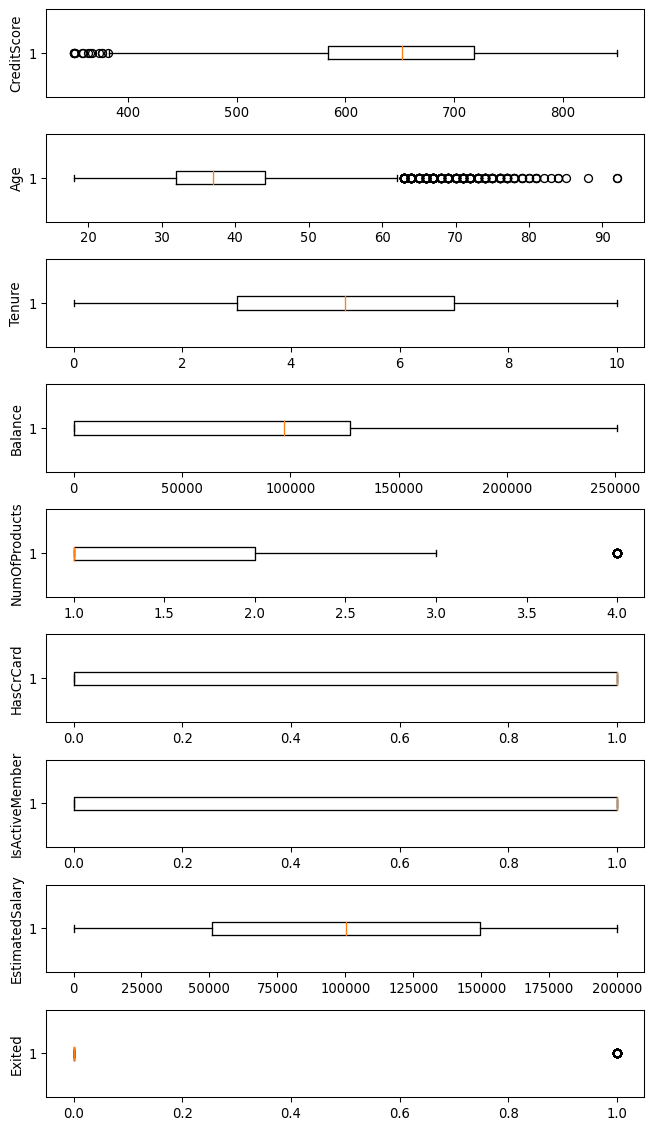

In [15]:
#Checking Outliers and If Valid
df2=df.drop(columns=['Year','Surname','CustomerId','Geography','Gender'])
df2.describe()
import matplotlib.pyplot as plt 
fig, axs = plt.subplots(len(df2.columns), 1, figsize=(7, 12), dpi=95)
for i, col in enumerate(df2.columns):
    axs[i].boxplot(df2[col], vert=False)
    axs[i].set_ylabel(col)
plt.tight_layout()
plt.show()

In [16]:
#Segmentation
def segmentation(df,seg):
    max_seg=df[seg].max()
    min_seg=df[seg].min()
    q1=df[seg].quantile(0.25)
    q3=df[seg].quantile(0.75)
    return max_seg,min_seg,q1,q3

In [17]:
#Age Segmentation
max_age,a,b,c=segmentation(df,'Age')
df1['Age']=pd.cut(df1['Age'], bins=[0,29,45,60,max_age], labels=['<30','30-45','46-60','60+'])

#Credit Score Segmentation
max_cs,min_cs,q1,q3=segmentation(df,'CreditScore')
df1['CreditScore']=pd.cut(df1['CreditScore'],bins=[min_cs-1,q1,q3,max_cs],
                          labels=['Low','Medium', 'High'])

#Tenure Segmentation
max_t,min_t,q1,q3=segmentation(df,'Tenure')
df1['Tenure']=pd.cut(df1['Tenure'],bins=[min_t-1,q1,q3-1,max_t],
                          labels=['New','Mid-Term', 'Long-Term'])

#Balance segmentation
max_b=df1['Balance'].max()
med_b = df1[df1['Balance'] > 0]['Balance'].median()
df1['Balance'] = pd.cut(df1['Balance'],bins=[-1,0,med_b,max_b ],
                        labels=['Zero_Bal', 'Low_Bal', 'High_Bal'])

In [18]:
#Task 4 Churn Distribution Analysis 15.06.26

In [19]:
#Overall Churn Rate
def churn_summary(df1):    
    total_cust=df1.shape[0]
    print(f"Total customers: {total_cust}")
    total_churn=df1['Exited'].sum()
    print(f"Total churned customers: {total_churn}")
    total_retain=total_cust-total_churn
    print(f"Total retained customers: {total_retain}")
    churn_rate = (df1['Exited'].mean()*100).round(2)
    retain_rate=100-churn_rate
    print(f"Overall churn rate: {churn_rate}")
    print(f"Overall retention rate: {retain_rate}")

In [20]:
#Segment-wise Churn Rate
# if 100 mem in Germany then 30 of them churned
segments=['Geography','Gender','Age','CreditScore','Tenure','Balance']
def seg_churn_rate(df1,segments):
    print("Segment-wise churn rates\n")
    for i in segments:
        churn_seg=(df1.groupby(i)['Exited'].mean().mul(100))
        x=churn_seg.plot(kind='bar',
                       color = ['pink', 'skyblue', 'yellow','lightgreen'],
                       figsize=(3,3))
        plt.title(f'Churn Rate (%) per {i} Segment')
        plt.ylabel('Churn Rate (%)')
        yield plt.gcf()
        plt.clf()
        plt.close()

In [21]:
#Churn contribution by segment size
#If 100 mem in total churned and Germany had 40 churned mem
print("Churn contribution by segment size\n")
def churn_contri_pie(df1,segments):
    for i in segments:
        churned_in_i=df1.groupby(i)['Exited'].sum()
        total_churned=df1['Exited'].sum()
        churn_contri=((churned_in_i*100)/(total_churned))
        churn_contri.plot(kind='pie', figsize=(5,3), autopct='%1.1f%%')
        plt.title(f'Churn Contribution By {i}')
        plt.ylabel('')
        yield plt.gcf()
        plt.clf()


Churn contribution by segment size



In [22]:
#Comparison of churned vs retained profiles

In [23]:
#Need More Segmentation For Comprehensive Comparison

#Estimated Salary Segmentation
max_s,min_s,q1,q3=segmentation(df,'EstimatedSalary')
df1['EstimatedSalary']=pd.cut(df1['EstimatedSalary'],bins=[min_s-1,q1,q3-1,max_s],
                          labels=['Low','Mid', 'High'])
#Num of Prod Segmentation
df1['NumOfProducts']=pd.cut(df1['NumOfProducts'],
                            bins=[0,1,4],
                           labels=['One','Multiple'])
#Has Cr Card and IsActiveMember
col=['HasCrCard','IsActiveMember']
for i in col:
    df1[i]=pd.cut(df1[i],
                  bins=[-1,0,1],
                  labels=['No','Yes'])
df1

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,Medium,France,Female,30-45,New,Zero_Bal,One,Yes,Yes,Mid,1
1,Medium,Spain,Female,30-45,New,Low_Bal,One,No,Yes,Mid,0
2,Low,France,Female,30-45,Long-Term,High_Bal,Multiple,Yes,No,Mid,1
3,Medium,France,Female,30-45,New,Zero_Bal,Multiple,No,No,Mid,0
4,High,Spain,Female,30-45,New,High_Bal,One,Yes,Yes,Mid,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,High,France,Male,30-45,Mid-Term,Zero_Bal,Multiple,Yes,No,Mid,0
9996,Low,France,Male,30-45,Long-Term,Low_Bal,One,Yes,Yes,Mid,0
9997,Medium,France,Female,30-45,Long-Term,Zero_Bal,One,No,Yes,Low,1
9998,High,Germany,Male,30-45,New,Low_Bal,Multiple,Yes,No,Mid,1


In [24]:
churned = (df1['Exited'] == 1).sum()
retained=(df1['Exited'] == 0).sum()
print(churned)
print(retained)

2037
7963


In [25]:
def seg_csv(df1,segments,name):
    max_churned={}
    max_retained={}
    max_churn_contri=[]
    max_retain_contri=[]
    for i in segments:
        churn_seg=(df1.groupby(i)['Exited'].mean().mul(100).round(2))
        churned_in_i=df1.groupby(i)['Exited'].sum()
        total_churned=df1['Exited'].sum()
        churn_contri=((churned_in_i*100)/(total_churned))
        max_churn_contri.append(churn_contri.idxmax())
        max_retain_contri.append(churn_contri.idxmin())
        max_churned[i]=churn_seg.idxmax()
        max_retained[i]=churn_seg.idxmin()
    hb_df = pd.DataFrame({
        'Segment': max_churned.keys(),
        'Highest Churn Rate': max_churned.values(),
        'Highest Churn Contributor': max_churn_contri,
        'Highest Retain Rate Per Segment': max_retained.values(),
        'Highest Retained Contributor': max_retain_contri
    })

    hb_df.to_csv(f"{name}.csv",index=False)
    return hb_df

In [26]:
segments=['CreditScore','Geography','Gender','Age','Tenure','Balance','NumOfProducts','HasCrCard',
          'IsActiveMember','EstimatedSalary']
seg_csv(df1,segments,"Summary")

,Segment,Highest Churn Rate,Highest Churn Contributor,Highest Retain Rate Per Segment,Highest Retained Contributor
0,CreditScore,Low,Medium,Medium,High
1,Geography,Germany,Germany,France,Spain
2,Gender,Female,Female,Male,Male
3,Age,46-60,30-45,<30,60+
4,Tenure,New,New,Long-Term,Mid-Term
5,Balance,High_Bal,High_Bal,Zero_Bal,Zero_Bal
6,NumOfProducts,One,One,Multiple,Multiple
7,HasCrCard,No,Yes,Yes,No
8,IsActiveMember,No,No,Yes,Yes
9,EstimatedSalary,High,Mid,Mid,Low


In [27]:
# Task 5 Comparative Demographic Analysis 16.06.26

In [28]:
#Gender-based churn difference
gender=df1.groupby('Gender')['Exited'].mean()
print(gender)

Gender
Female    0.250715
Male      0.164559
Name: Exited, dtype: float64


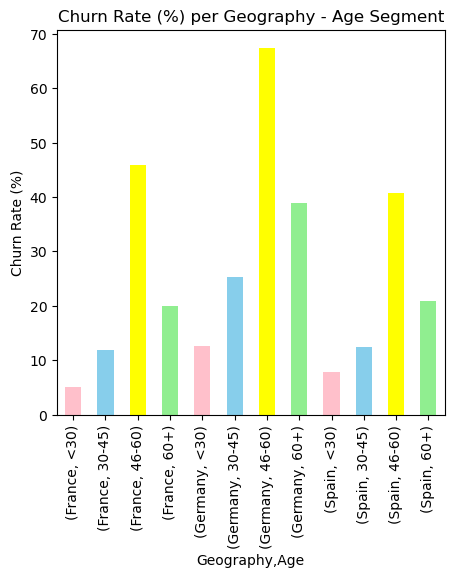

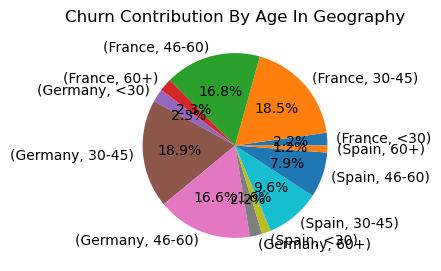

In [29]:
#Geography-Age Interaction Analysis
df1.groupby(['Geography','Age'])['Exited'].mean()
churn_seg=(df1.groupby(['Geography','Age'])['Exited'].mean().mul(100))
churn_seg.plot(kind='bar',
               color = ['pink', 'skyblue', 'yellow','lightgreen'],
                figsize=(5,5))
plt.title(f'Churn Rate (%) per Geography - Age Segment')
plt.ylabel('Churn Rate (%)')
plt.show()

churned_in_i=df1.groupby(['Geography','Age'])['Exited'].sum()
total_churned=df1['Exited'].sum()
churn_contri=((churned_in_i*100)/(total_churned))
churn_contri.plot(kind='pie', figsize=(5,3), autopct='%1.1f%%')
plt.title(f'Churn Contribution By Age In Geography')
plt.ylabel('')
plt.show()

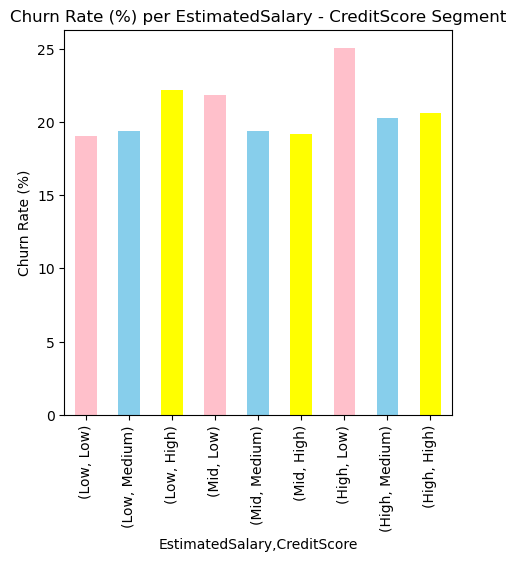

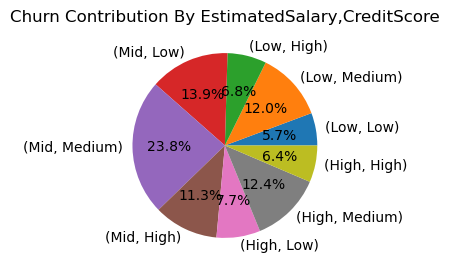

In [30]:
#Financial Stability Vs Churn
df1.groupby(['EstimatedSalary','CreditScore'])['Exited'].mean()
churn_seg=(df1.groupby(['EstimatedSalary','CreditScore'])['Exited'].mean().mul(100))
churn_seg.plot(kind='bar',
               color = ['pink', 'skyblue', 'yellow'],
                figsize=(5,5))
plt.title(f'Churn Rate (%) per EstimatedSalary - CreditScore Segment')
plt.ylabel('Churn Rate (%)')
plt.show()

churned_in_i=df1.groupby(['EstimatedSalary','CreditScore'])['Exited'].sum()
total_churned=df1['Exited'].sum()
churn_contri=((churned_in_i*100)/(total_churned))
churn_contri.plot(kind='pie', figsize=(5,3), autopct='%1.1f%%')
plt.title(f'Churn Contribution By EstimatedSalary,CreditScore')
plt.ylabel('')
plt.show()

In [31]:
#Task 6 High-Value Customer Churn Analysis 17.06.26

In [32]:
#Identify High balance churners
high_bal_df=df1[df1['Balance']=='High_Bal']
print(f"Total number of High Balance Customers: {high_bal_df.shape[0]}")
print(f"Total number of High Balance churners: {high_bal_df['Exited'].sum()}")
print(f"Churn rate among High Balance customers: {(high_bal_df['Exited'].mean()*100).round(2)}")
print(f"Retention rate among High Balance customers: {100-(high_bal_df['Exited'].mean()*100).round(2)}")
segments=['CreditScore','Geography','Gender','Age','Tenure','NumOfProducts','HasCrCard',
          'IsActiveMember','EstimatedSalary']
seg_csv(high_bal_df,segments,"High_Bal")

Total number of High Balance Customers: 3191
Total number of High Balance churners: 771
Churn rate among High Balance customers: 24.16
Retention rate among High Balance customers: 75.84


,Segment,Highest Churn Rate,Highest Churn Contributor,Highest Retain Rate Per Segment,Highest Retained Contributor
0,CreditScore,Low,Medium,High,High
1,Geography,Germany,Germany,Spain,Spain
2,Gender,Female,Female,Male,Male
3,Age,46-60,30-45,<30,60+
4,Tenure,Mid-Term,Long-Term,New,Mid-Term
5,NumOfProducts,One,One,Multiple,Multiple
6,HasCrCard,No,Yes,Yes,No
7,IsActiveMember,No,No,Yes,Yes
8,EstimatedSalary,Low,Mid,Mid,High


In [33]:
#Compare salary vs balance churn patterns
df1.groupby(['Balance','EstimatedSalary'])['Exited'].mean().mul(100).round(2)

Balance   EstimatedSalary
Zero_Bal  Low                13.05
          Mid                13.73
          High               14.81
Low_Bal   Low                22.60
          Mid                23.81
          High               25.74
High_Bal  Low                25.61
          Mid                23.12
          High               24.84
Name: Exited, dtype: float64

In [34]:
#Quantify revenue risk from churn
total_bal_lost=df[df['Exited']==1]['Balance'].sum()
print(f"Total Revenue lost : {total_bal_lost} Euros")
bal=df[df['Exited']==1].groupby('Geography')['Balance'].sum()
bal_per=((bal/total_bal_lost)*100).round(2)
print(f"Percentage of total churned balance contributed by each {bal_per}")

Total Revenue lost : 185588094.63 Euros
Percentage of total churned balance contributed by each Geography
France     31.07
Germany    52.79
Spain      16.14
Name: Balance, dtype: float64


In [35]:
#Task 7 : Engagement Drop Indicator 18.06.26

In [36]:
#Inactivity Vs Churn
churn_rate=df1.groupby("IsActiveMember")['Exited'].mean().mul(100).round(2)
churn_contri=(df1.groupby("IsActiveMember")['Exited'].sum()*100)/(df1['Exited'].sum())
print(churn_rate)
churn_contri

IsActiveMember
No     26.85
Yes    14.27
Name: Exited, dtype: float64


IsActiveMember
No     63.917526
Yes    36.082474
Name: Exited, dtype: float64

In [37]:
#saving segmented value fields dataset
df1.to_csv("New_European_Bank.csv",index=False)

In [38]:
#Age tenure comparison
import seaborn as sns

def age_tenure_heatmap(df1,seg_1,seg_2):

    age_tenure = (
        df1.groupby([seg_1, seg_2])['Exited']
           .mean()
           .mul(100)
           .round(2)
           .reset_index()
           .pivot(index=seg_1, columns=seg_2, values='Exited')
    )

    fig, ax = plt.subplots(figsize=(8, 5))

    sns.heatmap(
        age_tenure,
        annot=True,
        fmt='.1f',
        cmap='YlOrRd',
        ax=ax
    )

    ax.set_xlabel(seg_2)
    ax.set_ylabel(seg_1)

    return fig

In [39]:
#Dynamic Kpis
def dynamic_kpi(df1,a,sub_cate):#a means segment
    churn_seg = round(df1.loc[df1[a] == sub_cate, 'Exited'].mean() * 100,2)
    churned_in_i = df1.loc[df1[a] == sub_cate, 'Exited'].sum()
    total_churned = df1['Exited'].sum()
    churn_contri = round((churned_in_i * 100) / total_churned,2)
    high_val = round(df1.loc[(df1[a] == sub_cate) & (df1['Balance'] == 'High_Bal'),'Exited'].mean()*100,2)
    kpi={'ocr':churn_contri,'scr':churn_seg,'hvcr':high_val}
    return kpi

In [40]:
#High_val customer drill down view
def high_val_groupby(df1,a,sub_cate,hv_gb):
    return pd.DataFrame(df1[(df1[a]==sub_cate) & (df1['Balance']=='High_Bal')].groupby(hv_gb)['Exited'].mean().mul(100).round(2))